Este notebook apresenta um fluxo geral de utilização da biblioteca para a geração de IDFs, passando pelas etapas de processamento seguindo a ordem lógica necessária para a extração dos gráficos IDFs.

As explicações detalhadas de cada etapa, assim como exemplos dos métodos de processamento disponíveis se encontram nos notebooks de 01 à 05 neste diretório.

# Processamento dos dados

## Imports

In [33]:
import os
import pandas as pd

from idf_analysis.data.processing import read_csv, verification, fill_missing_data

from idf_analysis.data.reader import process_data, DataSource
from idf_analysis.data.processing import aggregate_to_csv

from idf_analysis.helpers.notebook import precip_summary

from idf_analysis.core.correlation import correlation_plots

## Processamento de dados

In [34]:
nome_estacao = "INMET_SAO_PAULO_MIRANTE"
nome_limpo = "sao_paulo_mirante"
pasta = f"../datasets/{nome_estacao}"
caminho_csv = os.path.join(pasta, f"inmet_{nome_limpo}.csv")
df = process_data(
    source=DataSource.INMET,
    data_path=caminho_csv,
)

aggregate_to_csv(
    df=df,
    name= 'inmet_' + nome_limpo,
    directory='../results/inmet_' + nome_limpo
)

nome_estacao = "INMET_DAILY_SAO_PAULO_MIRANTE"
nome_limpo = "daily_sao_paulo_mirante"
pasta = f"../datasets/{nome_estacao}"
caminho_csv = os.path.join(pasta, f"inmet_{nome_limpo}.csv")
df = process_data(
    source=DataSource.INMET,
    data_path=caminho_csv,
)

aggregate_to_csv(
    df=df,
    name= 'inmet_' + nome_limpo,
    directory='../results/inmet_' + nome_limpo
)

# CEMADEN
caminho_final = "../datasets/CEMADEN_AC_SANTANA_SAO"
nome_limpo = "cemaden_ac_santana_sao"

df = process_data(
    source=DataSource.CEMADEN,
    data_path=caminho_final,
    site_filter="API"
)

aggregate_to_csv(
    df=df,
    name= nome_limpo,
    directory='../results/' + nome_limpo,
    include_minutes=True,
    minute_freq=5
)

🔁 Processando dados do INMET...
✅ Detectado: INMET (horário)
🔁 Processando dados do INMET...
✅ Detectado: INMET_DAILY (diário)
🔁 Processando dados do DataSource.CEMADEN...

✅ Processamento concluído!



## Leitura dos datasets processados (Dataframe's)

In [35]:
cemaden_df = read_csv(path='../results/cemaden_ac_santana_sao/cemaden_ac_santana_sao_hourly.csv')
inmet_df = read_csv(path='../results/inmet_sao_paulo_mirante/inmet_sao_paulo_mirante_hourly.csv')
inmet_daily_df = read_csv(path='../results/inmet_daily_sao_paulo_mirante/inmet_daily_sao_paulo_mirante_daily.csv')

In [36]:
summary_hourly = pd.concat([
    precip_summary(inmet_df, "INMET Horário"),
    precip_summary(cemaden_df, "CEMADEN"),
    
])
print("📊 Base de dados para IDF's históricas: ")
display(summary_hourly.style.format(precision=2))

summary_daily = pd.concat([
    precip_summary(inmet_daily_df, "INMET Diário")
])

print("📊 Base de dados para correção de viés e IDF's de projeção futura: ")
display(summary_daily.style.format(precision=2))

📊 Base de dados para IDF's históricas: 


,Total registros,Registros > 0,Primeira data,Última data,Precipitação média (mm),Precipitação máxima (mm)
INMET Horário,96432,7266,2014-01-01 00:00:00,2024-12-31 23:00:00,0.17,77.80
CEMADEN,61305,6038,2014-01-01 00:00:00,2024-12-31 23:00:00,0.12,45.00


📊 Base de dados para correção de viés e IDF's de projeção futura: 


,Total registros,Registros > 0,Primeira data,Última data,Precipitação média (mm),Precipitação máxima (mm)
INMET Diário,12419,4594,1980-01-01 00:00:00,2013-12-31 00:00:00,4.46,151.80


## Verificação de falhas

In [37]:
verification(df=cemaden_df,frequency='hourly')
verification(df=inmet_df,frequency='hourly')

[WARNING] Série incompleta. Períodos faltando: 35127

[OK] Série completa! Nenhum período faltando.



{'status': 'complete', 'missing': 0}

## Verificando correlação dos dados entre os df's para completar os dados do CEMADEN com os dados do INMET

[INFO] Dados horários detectados → agregando para diário...
[INFO] Gerando scatter/regression com 4018 pontos...


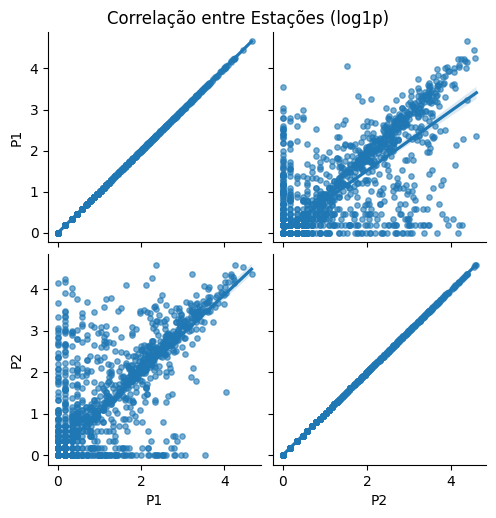


[INFO] ----- Resultados da Correlação -----

Matriz de Correlação (r de Pearson):
       P1     P2
P1 1.0000 0.7899
P2 0.7899 1.0000

Matriz de P-valores:
           P1         P2
P1 1.0000e+00 0.0000e+00
P2 0.0000e+00 1.0000e+00


(         P1       P2
 P1  1.00000  0.78991
 P2  0.78991  1.00000,
      P1   P2
 P1  1.0  0.0
 P2  0.0  1.0)

In [38]:
correlation_plots(cemaden_df, inmet_df)

Com o resultado acima de r = 0.7641, podemos ver numérica e graficamente a forte relação entre os dados dos dois datasets. Portanto, os dados do INMET se mostram satisfatoriamente coerentes para realizar o prenchimento dos dados faltantes do CEMADEN através de seus valores!

## Completando os dados faltantes

In [39]:
cemaden_df = fill_missing_data(
    df_main=cemaden_df,
	df_secondary=inmet_df,
    frequency='hourly'
)

# Verificando novamente após o preenchimento
verification(df=cemaden_df, frequency='hourly');

[OK] Série completa! Nenhum período faltando.



In [40]:
display(precip_summary(cemaden_df,'CEMADEN sem falhas').style.format(precision=2))

,Total registros,Registros > 0,Primeira data,Última data,Precipitação média (mm),Precipitação máxima (mm)
CEMADEN sem falhas,96432,26544,2014-01-01 00:00:00,2024-12-31 23:00:00,0.14,45.00


# Extração de Máximos  Subdiários

## Imports

In [41]:
from idf_analysis.analysis.historical.subdaily import get_max_subdaily_table
from idf_analysis.analysis.historical.intervals import DisaggregationScenario, get_subdaily_from_disaggregation_factors
from idf_analysis.core.distributions import get_distribution
from idf_analysis.analysis.historical.validation import max_annual_precipitation
from idf_analysis.analysis.historical.trend import run_trend_analysis

## Dados Subdiários (1h, 3h, 6h, 8h, 10h, 12h, 24h)

In [42]:
incomplete_subdaily_cemaden = get_max_subdaily_table(df=cemaden_df, name_file='cemaden_ac_santana_sao', output_dir='../results/cemaden_ac_santana_sao')

print("\n📊 CEMADEN - Máximos subdiários:")
display(incomplete_subdaily_cemaden)


incomplete_subdaily_inmet = get_max_subdaily_table(df=inmet_df, name_file='inmet_sao_paulo_mirante', output_dir='../results/inmet_sao_paulo_mirante')

print("\n📊 INMET - Máximos subdiários:")
display(incomplete_subdaily_inmet)


[OK] Resultados salvos em: ../results/cemaden_ac_santana_sao/max_subdaily_cemaden_ac_santana_sao.csv

📊 CEMADEN - Máximos subdiários:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h
0,2014,45.00,55.46,63.04,64.22,67.36,68.36,119.54
1,2015,43.99,89.54,94.08,94.28,94.48,94.48,104.33
2,2016,25.82,40.83,52.29,59.26,61.19,61.34,65.00
3,2017,26.84,55.56,67.17,67.97,68.35,70.52,87.44
4,2018,12.20,17.70,26.50,34.36,42.61,49.68,74.89
5,2019,25.98,31.88,34.25,36.14,36.14,36.34,46.46
6,2020,12.40,17.54,32.20,32.85,33.09,40.44,50.97
7,2021,11.14,21.41,29.53,37.09,42.20,44.06,57.36
8,2022,37.38,44.45,44.65,44.65,44.65,44.65,62.58
9,2023,30.74,41.03,43.01,43.81,43.81,44.20,56.44



[OK] Resultados salvos em: ../results/inmet_sao_paulo_mirante/max_subdaily_inmet_sao_paulo_mirante.csv

📊 INMET - Máximos subdiários:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h
0,2014,45.2,52.0,70.6,71.0,71.0,71.0,118.8
1,2015,77.8,87.2,87.2,87.2,87.2,87.2,100.0
2,2016,39.6,61.2,68.6,94.8,99.8,99.8,99.8
3,2017,64.6,97.0,101.8,113.4,113.4,113.4,121.8
4,2018,29.2,57.6,71.4,71.8,74.4,75.0,99.4
5,2019,67.6,88.0,92.6,94.0,94.2,94.2,126.4
6,2020,44.4,61.8,96.6,115.6,127.0,133.0,150.8
7,2021,31.0,48.4,48.4,48.6,49.4,49.4,63.6
8,2022,44.4,51.4,52.8,52.8,52.8,52.8,74.8
9,2023,56.6,61.8,73.0,73.6,75.4,76.0,81.0


## Dados Subdiários (5min, 10min, 15min, 20min, 25min e 30min)

In [43]:
var_value = 0.1 # Valor de exemplo para variação de precipitação

subdaily_cemaden = get_subdaily_from_disaggregation_factors(
    df=incomplete_subdaily_cemaden,
    scenario=DisaggregationScenario.BASE,
    var_value=var_value,
    frequency='hourly',
    name_file='cemaden_ac_santana_sao', 
    output_dir='../results/cemaden_ac_santana_sao',
    
)

print("\n📊 CEMADEN - Subdiários obtidos:")
display(subdaily_cemaden)
        
subdaily_inmet = get_subdaily_from_disaggregation_factors(
    df=incomplete_subdaily_inmet,
    scenario=DisaggregationScenario.BASE,
    var_value=var_value,
    frequency='hourly',
    name_file='inmet_sao_paulo_mirante',
    output_dir='../results/inmet_sao_paulo_mirante'
)

print("\n📊 INMET - Subdiários obtidos:")
display(subdaily_inmet)

[OK] Resultado salvo em: ../results/cemaden_ac_santana_sao/max_daily_cemaden_ac_santana_sao.csv

📊 CEMADEN - Subdiários obtidos:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h,Max_5min,Max_10min,Max_15min,Max_20min,Max_25min,Max_30min
0,2014,45.00,55.46,63.04,64.22,67.36,68.36,119.54,14.40,22.87,29.65,34.31,38.54,42.35
1,2015,43.99,89.54,94.08,94.28,94.48,94.48,104.33,12.57,19.96,25.88,29.94,33.64,36.97
2,2016,25.82,40.83,52.29,59.26,61.19,61.34,65.00,7.83,12.44,16.12,18.65,20.96,23.03
3,2017,26.84,55.56,67.17,67.97,68.35,70.52,87.44,10.53,16.73,21.69,25.09,28.19,30.98
4,2018,12.20,17.70,26.50,34.36,42.61,49.68,74.89,9.02,14.33,18.57,21.49,24.15,26.53
5,2019,25.98,31.88,34.25,36.14,36.14,36.34,46.46,5.60,8.89,11.52,13.33,14.98,16.46
6,2020,12.40,17.54,32.20,32.85,33.09,40.44,50.97,6.14,9.75,12.64,14.63,16.43,18.06
7,2021,11.14,21.41,29.53,37.09,42.20,44.06,57.36,6.91,10.97,14.23,16.46,18.49,20.32
8,2022,37.38,44.45,44.65,44.65,44.65,44.65,62.58,7.54,11.97,15.52,17.96,20.18,22.17
9,2023,30.74,41.03,43.01,43.81,43.81,44.20,56.44,6.80,10.80,14.00,16.20,18.20,20.00


[OK] Resultado salvo em: ../results/inmet_sao_paulo_mirante/max_daily_inmet_sao_paulo_mirante.csv

📊 INMET - Subdiários obtidos:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h,Max_5min,Max_10min,Max_15min,Max_20min,Max_25min,Max_30min
0,2014,45.2,52.0,70.6,71.0,71.0,71.0,118.8,14.31,22.73,29.46,34.09,38.30,42.09
1,2015,77.8,87.2,87.2,87.2,87.2,87.2,100.0,12.05,19.13,24.80,28.70,32.24,35.43
2,2016,39.6,61.2,68.6,94.8,99.8,99.8,99.8,12.02,19.09,24.75,28.64,32.18,35.36
3,2017,64.6,97.0,101.8,113.4,113.4,113.4,121.8,14.67,23.30,30.21,34.96,39.27,43.16
4,2018,29.2,57.6,71.4,71.8,74.4,75.0,99.4,11.97,19.02,24.65,28.53,32.05,35.22
5,2019,67.6,88.0,92.6,94.0,94.2,94.2,126.4,15.23,24.18,31.35,36.28,40.75,44.79
6,2020,44.4,61.8,96.6,115.6,127.0,133.0,150.8,18.17,28.85,37.40,43.28,48.62,53.43
7,2021,31.0,48.4,48.4,48.6,49.4,49.4,63.6,7.66,12.17,15.77,18.25,20.51,22.53
8,2022,44.4,51.4,52.8,52.8,52.8,52.8,74.8,9.01,14.31,18.55,21.47,24.12,26.50
9,2023,56.6,61.8,73.0,73.6,75.4,76.0,81.0,9.76,15.50,20.09,23.25,26.12,28.70


## Distribuição estatística da precipitação 

In [44]:
max_annual_cemaden = max_annual_precipitation(df=cemaden_df, name_file='cemaden_ac_santana_sao', output_dir='../results/cemaden_ac_santana_sao/', frequency='hourly')
max_annual_inmet_daily = max_annual_precipitation(df=inmet_daily_df, name_file='cemaden_ac_santana_sao', output_dir='../results/cemaden_ac_santana_sao/', frequency='hourly')

In [45]:
results_df, stats = run_trend_analysis(
    {
        'INMET': max_annual_inmet_daily
    }, 
    generate_plots=True,
    output_dir='../results/graphs/trend'
)


[INFO] Gráficos salvos em: ../results/graphs/trend



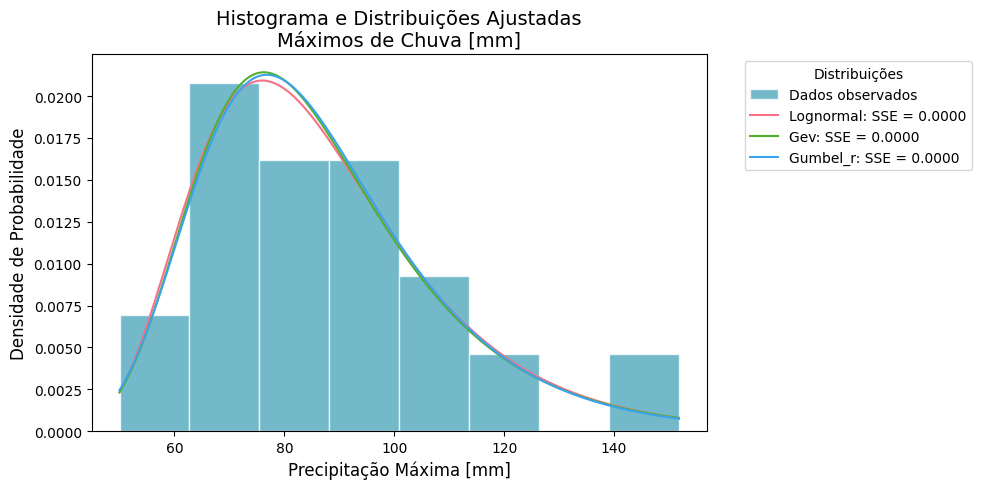

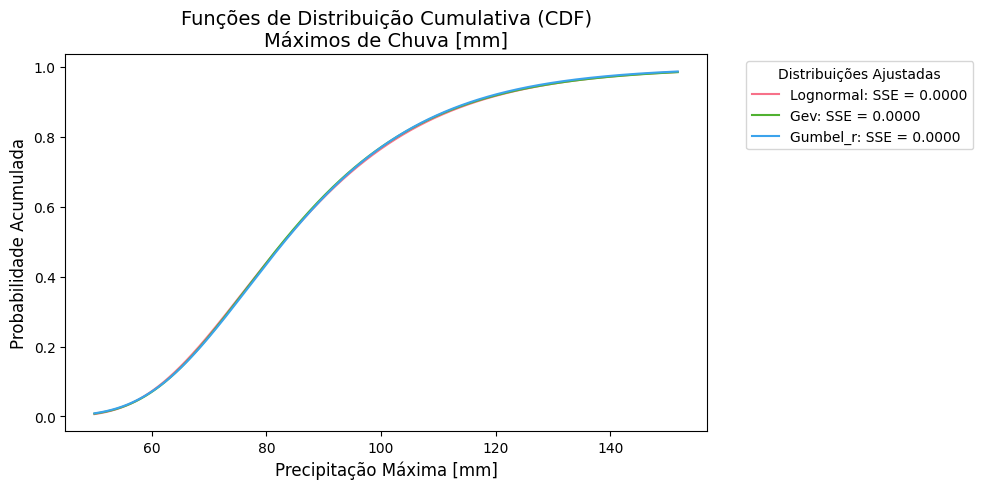

In [46]:
# Obtendo a distribuição estatística dos dados diários
get_distribution(data_df=max_annual_inmet_daily,column_name='Precipitation')

# Geração da curva IDF histórica

In [47]:
from idf_analysis.analysis.historical.idf import get_final_idf

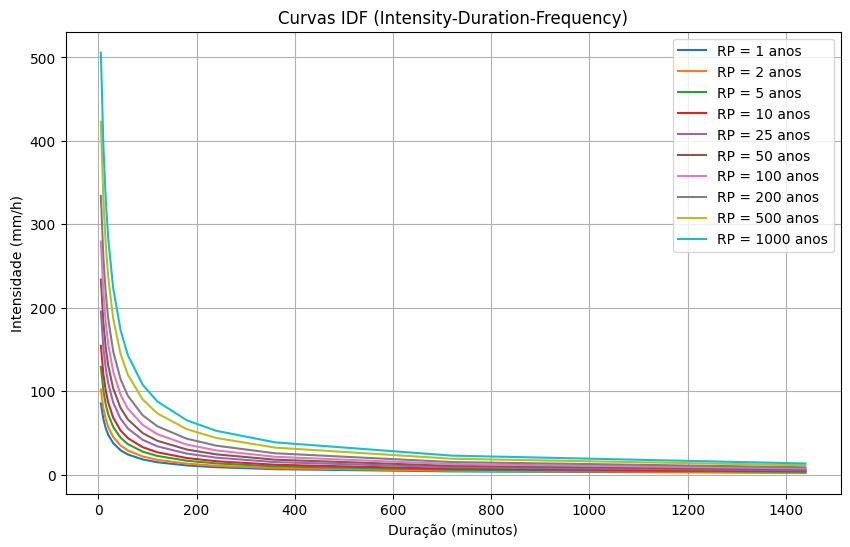

(np.float64(8.493644384051112),
 np.float64(0.7774828194914173),
 np.float64(645.2067653492036),
 np.float64(0.2575916059696733),
 None,
 None)

In [48]:
get_final_idf(
    name_file='cemaden_ac_santana_sao',
    directory='../results/cemaden_ac_santana_sao',
    disag_factor='ger',
    save_file=True,
    plot=True,
)